In [4]:
import polars as pl
import os

In [2]:
datalake_root = "/data/microns1412/"

In [5]:
datasets = pl.read_delta(os.path.join(datalake_root, "dataset/"))
datasets

id,name,publication,modality,project_id
str,str,str,str,str
"""minnie65_v1412_csm_cluster""","""Minnie65 v1412 CSM Dendrite Ul…","""none""","""ELECTRON_MICROSCOPY""","""minnie65"""
"""minnie65_v1412_proofread""","""Minnie65 v1412 Cells With Proo…","""none""","""ELECTRON_MICROSCOPY""","""minnie65"""


## Cell- cell connectivity

In [7]:
conn_df = pl.read_delta(os.path.join(datalake_root, "cellcellconnectivitylong/"))

In [13]:
conn_df.head()

id,description,presynaptic_cell,postsynaptic_cell,modality,value,unit,project_id,measurement_type
str,str,str,str,str,f64,str,str,str
"""43176584""",null,"""337175""","""304043""",null,5984.0,"""ARBITRARY_UNIT""","""minnie65""","""SUM_ANATOMICAL_SIZE"""
"""43181492""",null,"""330167""","""339142""",null,5920.0,"""ARBITRARY_UNIT""","""minnie65""","""SUM_ANATOMICAL_SIZE"""
"""43181499""",null,"""273595""","""339142""",null,3852.0,"""ARBITRARY_UNIT""","""minnie65""","""SUM_ANATOMICAL_SIZE"""
"""43183398""",null,"""301121""","""339142""",null,11504.0,"""ARBITRARY_UNIT""","""minnie65""","""SUM_ANATOMICAL_SIZE"""
"""43183978""",null,"""273595""","""205051""",null,6244.0,"""ARBITRARY_UNIT""","""minnie65""","""SUM_ANATOMICAL_SIZE"""


In [22]:
collist = ['project_id', 'modality', 'measurement_type']

for c, cc in enumerate(collist):
    print(conn_df.select(pl.col(cc).unique()).to_series().to_list())

['minnie65']
[None]
['SUM_ANATOMICAL_SIZE', 'SYNAPSE_COUNT']


### unique pre and post

In [24]:
collist = ['presynaptic_cell', 'postsynaptic_cell']

for c, cc in enumerate(collist):
    print(cc, len(conn_df.select(pl.col(cc).unique()).to_series().to_list()))

presynaptic_cell 1962
postsynaptic_cell 63221


## Cell feature definition

In [32]:
featdef_df = pl.read_delta(os.path.join(datalake_root, 'cellfeaturedefinition'))

In [28]:
featdef_df

id,description,unit,data_type,range_min,range_max
str,str,str,str,f64,f64
"""x_umap""","""umap low dimensional embedding…","""ARBITRARY_UNIT""","""<f4""",null,null
"""y_umap""","""umap low dimensional embedding…","""ARBITRARY_UNIT""","""<f4""",null,null
"""x_medial-lateral""","""The x coordinate in minnie65 a…","""MICRONS_LENGTH""","""<f4""",null,null
"""y_dorsal-ventral""","""The y coordinate in minnie65 a…","""MICRONS_LENGTH""","""<f4""",null,null
"""z_caudal-rostral""","""The z coordinate in minnie65 a…","""MICRONS_LENGTH""","""<f4""",null,null
…,…,…,…,…,…
"""branch_svd3""","""SVD loading dendritic path len…","""RATIO""","""<f4""",NaN,NaN
"""branch_svd4""","""SVD loading dendritic path len…","""RATIO""","""<f4""",NaN,NaN
"""ego_count_pca0""","""PC loading synapse depth relat…","""RATIO""","""<f4""",NaN,NaN


## Cell features

In [51]:
cell_features = pl.read_delta(os.path.join(datalake_root, 'cellfeatures/csm_cluster_features'))
cell_features.head()

id,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,tip_len_dist_dendrite_p75,tip_tort_dendrite_p75,num_syn_dendrite,num_syn_soma,path_length_dendrite,radial_extent_dendrite,syn_dist_distribution_dendrite_p50,syn_size_distribution_soma_p50,syn_size_distribution_dendrite_p50,syn_size_distribution_dendrite_p5,syn_size_distribution_dendrite_p95,syn_size_dendrite_cv,syn_depth_dist_p1,syn_depth_dist_p99,syn_depth_extent,median_density,radius_dist,area_factor,dendrite_length_binned_0,dendrite_length_binned_1,dendrite_length_binned_2,dendrite_length_binned_3,syn_dist_distribution_dendrite_spine_p50,syn_dist_distribution_dendrite_shaft_p50,dend_spine_shaft_offset,…,median_density_shaft,syn_spine_shaft_ratio_dendrite,num_spine_syn_dendrite,num_shaft_syn_dendrite,num_spine_syn_soma,syn_count_dist_binned_shaft_0,syn_count_dist_binned_shaft_1,syn_count_dist_binned_shaft_2,syn_count_dist_binned_shaft_3,syn_count_dist_binned_spine_0,syn_count_dist_binned_spine_1,syn_count_dist_binned_spine_2,syn_count_dist_binned_spine_3,syn_count_dist_binned_ratio_0,syn_count_dist_binned_ratio_1,syn_count_dist_binned_ratio_2,syn_count_dist_binned_ratio_3,syn_count_pca0,syn_count_pca1,syn_count_pca2,syn_count_pca3,syn_count_pca4,syn_count_pca5,syn_count_pca6,syn_count_pca7,syn_count_pca8,syn_count_pca9,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i32,f32,f32,f32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""485509""",344.116638,269.338379,0.782695,4.873741e6,0.017687,0.309179,1112.999878,1202.533447,537.42511,1.080443,0.15817,147.846939,1.264484,6768,117,4849.900391,227.368088,88.470299,3532,4340,596,28359,1.170447,27.544989,173.108597,145.563599,1.422885,385.890778,2.670925,818.647766,1723.804077,1067.032959,438.294983,88.60463,90.456306,-1.851673,…,0.414144,1.269837,4718,1956,0,371,721,407,209,606,2213,1268,405,0.706394,1.616585,1.637051,0.95109,5.812237,0.119504,-0.61887,-0.880462,-0.127526,-0.166496,0.165302,-0.123148,1.384805,-0.181554,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,"""minnie65""","""csm_cluster_features"""
"""263203""",254.538391,250.433167,0.983872,3.075656e7,0.123807,0.397382,640.53772,934.029358,361.333221,1.458196,0.119974,152.7453,1.301633,2036,45,2394.644043,115.675705,74.979202,4564,4618,737,21603,0.944691,23.207253,425.879395,402.672119,0.860583,319.731171,2.512924,508.080261,855.880737,473.234985,117.005539,76.613541,74.566284,2.047251,…,0.189176,1.760139,1547,456,2,133,165,78,18,339,729,340,70,1.343302,2.136713,2.109847,1.90182,-1.764601,-2.52387,-0.272709,-2.189014,-1.03418,-0.030833,0.031632,-0.05569,0.326676,-2.280065,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,"""minnie65""","""csm_cluster_features"""
"""456177""",338.026459,298.603607,0.883373,3.5204028e7,0.124294,0.366174,923.129578,1017.687988,365.622009,1.102432,0.189111,153.671768,1.35095,4380,124,4331.236816,107.554108,86.69693,4408,5460,695,26492,0.97058,14.459391,330.694427,316.235046,1.02033,333.71936,2.624826,639.515625,1594.599854,1216.418457,168.38266,88.55098,86.423515,2.127462,…,0.27645,1.333254,3068,1217,0,246,446,278,56,406,1462,951,101,0.720518,1.710583,1.770696,0.839535,-0.915223,-1.138865,-0.62281,4.627585,-0.271961,-0.14354,0.484421,-0.112422,0.98503,-0.476574,56.717365,4.266992,9.26533,-0.329062,7.591257,-0.729798,-0.946995,0.546816,"""minnie65""","""csm_cluster_features"""
"""461339""",328.602386,300.213623,0.913608,3.8599868e7,0.126401,0.324381,1013.014954,1051.013306,1082.797363,1.03

In [52]:
cell_features.columns

['id',
 'nucleus_volume_um',
 'nucleus_area_um',
 'nuclear_area_to_volume_ratio',
 'nuclear_folding_area_um',
 'fraction_nuclear_folding',
 'nucleus_to_soma_ratio',
 'soma_volume_um',
 'soma_area_um',
 'soma_to_nucleus_center_dist',
 'soma_area_to_volume_ratio',
 'soma_synapse_density_um',
 'tip_len_dist_dendrite_p75',
 'tip_tort_dendrite_p75',
 'num_syn_dendrite',
 'num_syn_soma',
 'path_length_dendrite',
 'radial_extent_dendrite',
 'syn_dist_distribution_dendrite_p50',
 'syn_size_distribution_soma_p50',
 'syn_size_distribution_dendrite_p50',
 'syn_size_distribution_dendrite_p5',
 'syn_size_distribution_dendrite_p95',
 'syn_size_dendrite_cv',
 'syn_depth_dist_p1',
 'syn_depth_dist_p99',
 'syn_depth_extent',
 'median_density',
 'radius_dist',
 'area_factor',
 'dendrite_length_binned_0',
 'dendrite_length_binned_1',
 'dendrite_length_binned_2',
 'dendrite_length_binned_3',
 'syn_dist_distribution_dendrite_spine_p50',
 'syn_dist_distribution_dendrite_shaft_p50',
 'dend_spine_shaft_offset

## Cell feature set

In [56]:
cell_feature_sets = pl.read_delta(os.path.join(datalake_root, 'cellfeatureset'))
cell_feature_sets

id,description,feature_definition_ids,extraction_method
str,str,list[str],str
"""csm_cluster_features_umap""","""Umap reduction fo the features…","[""x_umap"", ""y_umap""]","""umap_learn"""
"""minnie65_std_transform_coordin…","""The coordinates of the cell so…","[""x_medial-lateral"", ""y_dorsal-ventral"", ""z_caudal-rostral""]","""Applied standard_transform to …"
"""csm_cluster_features""","""Cell features used for cluster…","[""nucleus_volume_um"", ""nucleus_area_um"", … ""ego_count_pca2""]","""Aggegated and computed via htt…"


## Clusters and cluster members

In [38]:
clusters=pl.read_delta(os.path.join(datalake_root, "cluster"))
cluster_members =pl.read_delta(os.path.join(datalake_root, "clustermembership"))

In [41]:
clusters

id,parent,children,level,score,hex_color,heirachy_category,distance_to_parent,project_id
str,str,list[str],i64,f64,str,str,f64,str
"""neuron""",null,"[""glutamatergic"", ""gabaergic""]",0,null,"""#000000""","""major_class""",null,"""minnie65"""
"""gabaergic""","""neuron""","[""PTC"", ""DTC"", … ""STC""]",1,null,"""#0000FF""","""class""",null,"""minnie65"""
"""glutamatergic""","""neuron""","[""L4IT"", ""L6CT"", … ""L6SP""]",1,null,"""#FF0000""","""class""",null,"""minnie65"""
"""PTC""","""gabaergic""",null,2,null,"""#364a7a""","""subtype""",null,"""minnie65"""
"""DTC""","""gabaergic""",null,2,null,"""#80c5c0""","""subtype""",null,"""minnie65"""
…,…,…,…,…,…,…,…,…
"""L5IT""","""glutamatergic""",null,2,null,"""#b76969""","""subtype""",null,"""minnie65"""
"""L6IT""","""glutamatergic""",null,2,null,"""#7d354c""","""subtype""",null,"""minnie65"""
"""L5ET""","""glutamatergic""",null,2,null,"""#c68076""","""subtype""",null,"""minnie65"""


In [40]:
cluster_members.head()

item,cluster,membership_score,probability,distance,project_id
str,str,f64,f64,f64,str
"""204945""","""neuron""",null,1.0,null,"""minnie65"""
"""204945""","""glutamatergic""",null,null,null,"""minnie65"""
"""204945""","""L6CT""",null,null,null,"""minnie65"""
"""524777""","""neuron""",null,1.0,null,"""minnie65"""
"""524777""","""glutamatergic""",null,null,null,"""minnie65"""


In [42]:
cluster_members.height

107340

## filter 2nd level cell types

In [48]:
cell_types = cluster_members.join(clusters, left_on='cluster', right_on='id')
cell_types = cell_types.filter(pl.col('level')==2)

In [49]:
cell_types

item,cluster,membership_score,probability,distance,project_id,parent,children,level,score,hex_color,heirachy_category,distance_to_parent,project_id_right
str,str,f64,f64,f64,str,str,list[str],i64,f64,str,str,f64,str
"""204945""","""L6CT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#924455""","""subtype""",null,"""minnie65"""
"""524777""","""L4IT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#d29685""","""subtype""",null,"""minnie65"""
"""407636""","""L6CT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#924455""","""subtype""",null,"""minnie65"""
"""493863""","""L5IT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#b76969""","""subtype""",null,"""minnie65"""
"""565653""","""L6CT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#924455""","""subtype""",null,"""minnie65"""
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""269402""","""L5IT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#b76969""","""subtype""",null,"""minnie65"""
"""311962""","""L6CT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#924455""","""subtype""",null,"""minnie65"""
"""269817""","""L6IT""",null,null,null,"""minnie65""","""glutamatergic""",null,2,null,"""#7d354c""","""subtype""",null,"""minnie65"""


## add cell features per cell

In [53]:
nodes=cell_types.select(["item", "cluster", "parent"]).join(cell_features, left_on="item", right_on="id")

In [54]:
nodes

item,cluster,parent,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,tip_len_dist_dendrite_p75,tip_tort_dendrite_p75,num_syn_dendrite,num_syn_soma,path_length_dendrite,radial_extent_dendrite,syn_dist_distribution_dendrite_p50,syn_size_distribution_soma_p50,syn_size_distribution_dendrite_p50,syn_size_distribution_dendrite_p5,syn_size_distribution_dendrite_p95,syn_size_dendrite_cv,syn_depth_dist_p1,syn_depth_dist_p99,syn_depth_extent,median_density,radius_dist,area_factor,dendrite_length_binned_0,dendrite_length_binned_1,dendrite_length_binned_2,dendrite_length_binned_3,syn_dist_distribution_dendrite_spine_p50,…,median_density_shaft,syn_spine_shaft_ratio_dendrite,num_spine_syn_dendrite,num_shaft_syn_dendrite,num_spine_syn_soma,syn_count_dist_binned_shaft_0,syn_count_dist_binned_shaft_1,syn_count_dist_binned_shaft_2,syn_count_dist_binned_shaft_3,syn_count_dist_binned_spine_0,syn_count_dist_binned_spine_1,syn_count_dist_binned_spine_2,syn_count_dist_binned_spine_3,syn_count_dist_binned_ratio_0,syn_count_dist_binned_ratio_1,syn_count_dist_binned_ratio_2,syn_count_dist_binned_ratio_3,syn_count_pca0,syn_count_pca1,syn_count_pca2,syn_count_pca3,syn_count_pca4,syn_count_pca5,syn_count_pca6,syn_count_pca7,syn_count_pca8,syn_count_pca9,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i32,f32,f32,f32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""485509""","""L2IT""","""glutamatergic""",344.116638,269.338379,0.782695,4.873741e6,0.017687,0.309179,1112.999878,1202.533447,537.42511,1.080443,0.15817,147.846939,1.264484,6768,117,4849.900391,227.368088,88.470299,3532,4340,596,28359,1.170447,27.544989,173.108597,145.563599,1.422885,385.890778,2.670925,818.647766,1723.804077,1067.032959,438.294983,88.60463,…,0.414144,1.269837,4718,1956,0,371,721,407,209,606,2213,1268,405,0.706394,1.616585,1.637051,0.95109,5.812237,0.119504,-0.61887,-0.880462,-0.127526,-0.166496,0.165302,-0.123148,1.384805,-0.181554,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,"""minnie65""","""csm_cluster_features"""
"""263203""","""L4IT""","""glutamatergic""",254.538391,250.433167,0.983872,3.075656e7,0.123807,0.397382,640.53772,934.029358,361.333221,1.458196,0.119974,152.7453,1.301633,2036,45,2394.644043,115.675705,74.979202,4564,4618,737,21603,0.944691,23.207253,425.879395,402.672119,0.860583,319.731171,2.512924,508.080261,855.880737,473.234985,117.005539,76.613541,…,0.189176,1.760139,1547,456,2,133,165,78,18,339,729,340,70,1.343302,2.136713,2.109847,1.90182,-1.764601,-2.52387,-0.272709,-2.189014,-1.03418,-0.030833,0.031632,-0.05569,0.326676,-2.280065,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,"""minnie65""","""csm_cluster_features"""
"""456177""","""L3IT""","""glutamatergic""",338.026459,298.603607,0.883373,3.5204028e7,0.124294,0.366174,923.129578,1017.687988,365.622009,1.102432,0.189111,153.671768,1.35095,4380,124,4331.236816,107.554108,86.69693,4408,5460,695,26492,0.97058,14.459391,330.694427,316.235046,1.02033,333.71936,2.624826,639.515625,1594.599854,1216.418457,168.38266,88.55098,…,0.27645,1.333254,3068,1217,0,246,446,278,56,406,1462,951,101,0.720518,1.710583,1.770696,0.839535,-0.915223,-1.138865,-0.62281,4.627585,-0.271961,-0.14354,0.484421,-0.112422,0.98503,-0.476574,56.717365,4.266992,9.26533,-0.329062,7.591257,-0.729798,-0.946995,0.546816,"""minnie65""","""csm_cluster_features"""
"""461339""","""L5IT""","""glutamatergic""",328.602386,300.213623,0.913608,3.8599868e7,0.126401,0.324381,1013.014954,1051.01330

## filter csm features

In [58]:
feature_set = cell_feature_sets.filter(pl.col("id") == "csm_cluster_features")
features =  featdef_df.filter(pl.col('id').is_in(feature_set['feature_definition_ids']))
features

id,description,unit,data_type,range_min,range_max
str,str,str,str,f64,f64
"""nucleus_volume_um""","""Nucleus volume""","""MICRONS_CUBED""","""<f4""",0.0,NaN
"""nucleus_area_um""","""Nucleus surface area""","""MICRONS_SQUARE""","""<f4""",0.0,NaN
"""nuclear_area_to_volume_ratio""","""Nucleus surface area to volume…","""MICRONS_INVERSE""","""<f4""",0.0,NaN
"""nuclear_folding_area_um""","""Area of nucleus in an infoldin…","""MICRONS_SQUARE""","""<f4""",0.0,NaN
"""fraction_nuclear_folding""","""Fraction of nucleus in an info…","""RATIO""","""<f4""",0.0,1.0
…,…,…,…,…,…
"""branch_svd3""","""SVD loading dendritic path len…","""RATIO""","""<f4""",NaN,NaN
"""branch_svd4""","""SVD loading dendritic path len…","""RATIO""","""<f4""",NaN,NaN
"""ego_count_pca0""","""PC loading synapse depth relat…","""RATIO""","""<f4""",NaN,NaN


# Plot adjacency matrix
using    
nodes: cell features per cell for feature panels   
, and    
results: synapse table filteres for "synaptic weight" for adjacency matrix

In [65]:
from utils import adjacencyplot
import numpy as np
from matplotlib import pyplot as plt


## make cell type palette

In [59]:
cell_type_palette={}
for row in clusters.rows():
    cell_type_palette[row[0]]=row[5]

In [92]:
result = conn_df.filter(pl.col("measurement_type") == "SYNAPSE_COUNT")

In [93]:
result

id,description,presynaptic_cell,postsynaptic_cell,modality,value,unit,project_id,measurement_type
str,str,str,str,str,f64,str,str,str
"""43176584""",null,"""337175""","""304043""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""43181492""",null,"""330167""","""339142""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""43181499""",null,"""273595""","""339142""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""43183398""",null,"""301121""","""339142""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""43183978""",null,"""273595""","""205051""",null,2.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
…,…,…,…,…,…,…,…,…
"""303199984""",null,"""497103""","""422139""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""303200956""",null,"""463716""","""422139""",null,1.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""
"""303201438""",null,"""490761""","""422139""",null,2.0,"""COUNT""","""minnie65""","""SYNAPSE_COUNT"""


In [71]:
nodes

item,cluster,parent,nucleus_volume_um,nucleus_area_um,nuclear_area_to_volume_ratio,nuclear_folding_area_um,fraction_nuclear_folding,nucleus_to_soma_ratio,soma_volume_um,soma_area_um,soma_to_nucleus_center_dist,soma_area_to_volume_ratio,soma_synapse_density_um,tip_len_dist_dendrite_p75,tip_tort_dendrite_p75,num_syn_dendrite,num_syn_soma,path_length_dendrite,radial_extent_dendrite,syn_dist_distribution_dendrite_p50,syn_size_distribution_soma_p50,syn_size_distribution_dendrite_p50,syn_size_distribution_dendrite_p5,syn_size_distribution_dendrite_p95,syn_size_dendrite_cv,syn_depth_dist_p1,syn_depth_dist_p99,syn_depth_extent,median_density,radius_dist,area_factor,dendrite_length_binned_0,dendrite_length_binned_1,dendrite_length_binned_2,dendrite_length_binned_3,syn_dist_distribution_dendrite_spine_p50,…,median_density_shaft,syn_spine_shaft_ratio_dendrite,num_spine_syn_dendrite,num_shaft_syn_dendrite,num_spine_syn_soma,syn_count_dist_binned_shaft_0,syn_count_dist_binned_shaft_1,syn_count_dist_binned_shaft_2,syn_count_dist_binned_shaft_3,syn_count_dist_binned_spine_0,syn_count_dist_binned_spine_1,syn_count_dist_binned_spine_2,syn_count_dist_binned_spine_3,syn_count_dist_binned_ratio_0,syn_count_dist_binned_ratio_1,syn_count_dist_binned_ratio_2,syn_count_dist_binned_ratio_3,syn_count_pca0,syn_count_pca1,syn_count_pca2,syn_count_pca3,syn_count_pca4,syn_count_pca5,syn_count_pca6,syn_count_pca7,syn_count_pca8,syn_count_pca9,branch_svd0,branch_svd1,branch_svd2,branch_svd3,branch_svd4,ego_count_pca0,ego_count_pca1,ego_count_pca2,project_id,feature_set_id
str,str,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,i32,i32,f32,f32,f32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,…,f32,f32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,i32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,str
"""485509""","""L2IT""","""glutamatergic""",344.116638,269.338379,0.782695,4.873741e6,0.017687,0.309179,1112.999878,1202.533447,537.42511,1.080443,0.15817,147.846939,1.264484,6768,117,4849.900391,227.368088,88.470299,3532,4340,596,28359,1.170447,27.544989,173.108597,145.563599,1.422885,385.890778,2.670925,818.647766,1723.804077,1067.032959,438.294983,88.60463,…,0.414144,1.269837,4718,1956,0,371,721,407,209,606,2213,1268,405,0.706394,1.616585,1.637051,0.95109,5.812237,0.119504,-0.61887,-0.880462,-0.127526,-0.166496,0.165302,-0.123148,1.384805,-0.181554,62.978085,0.950874,0.729539,-1.328438,4.192588,1.960875,0.805681,-0.739578,"""minnie65""","""csm_cluster_features"""
"""263203""","""L4IT""","""glutamatergic""",254.538391,250.433167,0.983872,3.075656e7,0.123807,0.397382,640.53772,934.029358,361.333221,1.458196,0.119974,152.7453,1.301633,2036,45,2394.644043,115.675705,74.979202,4564,4618,737,21603,0.944691,23.207253,425.879395,402.672119,0.860583,319.731171,2.512924,508.080261,855.880737,473.234985,117.005539,76.613541,…,0.189176,1.760139,1547,456,2,133,165,78,18,339,729,340,70,1.343302,2.136713,2.109847,1.90182,-1.764601,-2.52387,-0.272709,-2.189014,-1.03418,-0.030833,0.031632,-0.05569,0.326676,-2.280065,31.198191,-4.262416,0.754856,1.729803,1.534398,0.588246,-0.777625,-0.096427,"""minnie65""","""csm_cluster_features"""
"""456177""","""L3IT""","""glutamatergic""",338.026459,298.603607,0.883373,3.5204028e7,0.124294,0.366174,923.129578,1017.687988,365.622009,1.102432,0.189111,153.671768,1.35095,4380,124,4331.236816,107.554108,86.69693,4408,5460,695,26492,0.97058,14.459391,330.694427,316.235046,1.02033,333.71936,2.624826,639.515625,1594.599854,1216.418457,168.38266,88.55098,…,0.27645,1.333254,3068,1217,0,246,446,278,56,406,1462,951,101,0.720518,1.710583,1.770696,0.839535,-0.915223,-1.138865,-0.62281,4.627585,-0.271961,-0.14354,0.484421,-0.112422,0.98503,-0.476574,56.717365,4.266992,9.26533,-0.329062,7.591257,-0.729798,-0.946995,0.546816,"""minnie65""","""csm_cluster_features"""
"""461339""","""L5IT""","""glutamatergic""",328.602386,300.213623,0.913608,3.8599868e7,0.126401,0.324381,1013.014954,1051.01330

(<Axes: >, <utils.AxisGrid at 0x7fe8fac38260>)

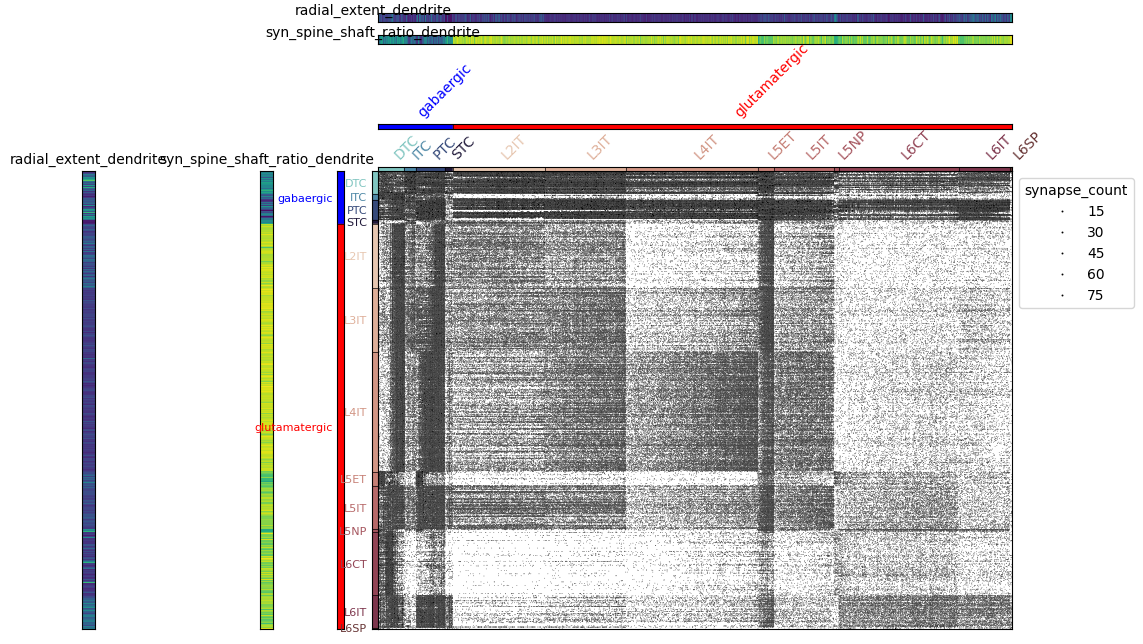

In [77]:
df=result.to_pandas()
node_df = nodes.to_pandas()
df['synapse_count'] = df.value
f, ax = plt.subplots(figsize=(12,8))
adjacencyplot(df,
              node_df,
              node_id_col="item",
              row_groupby=["parent", "cluster"],
              col_groupby=["parent", "cluster"],
              col_sortby=["median_density"],
              node_palette=cell_type_palette,
              pre_id_col="presynaptic_cell",
              post_id_col="postsynaptic_cell",
              arc_labels = None,
              weight_col="synapse_count",
              plot_type="scattermap",
              row_value_bars=["syn_spine_shaft_ratio_dendrite","radial_extent_dendrite"],
              col_value_bars=["syn_spine_shaft_ratio_dendrite","radial_extent_dendrite"],
              edge_hue=False,
              hue_norm=(1,10),
              sizes = (.1, 2),
              size_norm=(0,13),
              ax=ax)

In [75]:
# list of features
nodes.columns

['item',
 'cluster',
 'parent',
 'nucleus_volume_um',
 'nucleus_area_um',
 'nuclear_area_to_volume_ratio',
 'nuclear_folding_area_um',
 'fraction_nuclear_folding',
 'nucleus_to_soma_ratio',
 'soma_volume_um',
 'soma_area_um',
 'soma_to_nucleus_center_dist',
 'soma_area_to_volume_ratio',
 'soma_synapse_density_um',
 'tip_len_dist_dendrite_p75',
 'tip_tort_dendrite_p75',
 'num_syn_dendrite',
 'num_syn_soma',
 'path_length_dendrite',
 'radial_extent_dendrite',
 'syn_dist_distribution_dendrite_p50',
 'syn_size_distribution_soma_p50',
 'syn_size_distribution_dendrite_p50',
 'syn_size_distribution_dendrite_p5',
 'syn_size_distribution_dendrite_p95',
 'syn_size_dendrite_cv',
 'syn_depth_dist_p1',
 'syn_depth_dist_p99',
 'syn_depth_extent',
 'median_density',
 'radius_dist',
 'area_factor',
 'dendrite_length_binned_0',
 'dendrite_length_binned_1',
 'dendrite_length_binned_2',
 'dendrite_length_binned_3',
 'syn_dist_distribution_dendrite_spine_p50',
 'syn_dist_distribution_dendrite_shaft_p50',


In [91]:
# number of pre and postsynaptic ids in the matrix above

node_ids = nodes["item"].cast(result["presynaptic_cell"].dtype).unique()
filtered = result.filter(
    pl.col("presynaptic_cell").is_in(node_ids) & pl.col("postsynaptic_cell").is_in(node_ids)
)
result = ['presynaptic_cell', 'postsynaptic_cell']

for c, cc in enumerate(collist):
    print(cc, len(filtered.select(pl.col(cc).unique()).to_series().to_list()))

presynaptic_cell 1861
postsynaptic_cell 34610


/tmp/ipykernel_119/3821486988.py:4: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
  filtered = result.filter(
